# File này xử lý việc Phân tích và Tiền xử lý Dữ liệu, các file khác dùng file dataset.csv để dùng data đã được xử lý


## 1. Mô tả dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. MÔ TẢ DỮ LIỆU
# Đọc file Excel
df = pd.read_excel('data/Dry_Bean_Dataset.xlsx')

print(f"Kích thước dữ liệu: {df.shape}")
print("\nThông tin các cột:")
print(df.info())
# Biến mục tiêu là 'Class' (loại hạt đậu)

Kích thước dữ liệu: (13611, 17)

Thông tin các cột:
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            

## 2. Phân tích khám phá (EDA):

### 1. Thống kê mô tả: mean, std, min, max, tứ phân vị.

In [46]:
# Thống kê mô tả các biến số
print(df.describe())


                Area     Perimeter  MajorAxisLength  MinorAxisLength  \
count   13611.000000  13611.000000     13611.000000     13611.000000   
mean    53048.284549    855.283459       320.141867       202.270714   
std     29324.095717    214.289696        85.694186        44.970091   
min     20420.000000    524.736000       183.601165       122.512653   
25%     36328.000000    703.523500       253.303633       175.848170   
50%     44652.000000    794.941000       296.883367       192.431733   
75%     61332.000000    977.213000       376.495012       217.031741   
max    254616.000000   1985.370000       738.860153       460.198497   

       AspectRation  Eccentricity     ConvexArea  EquivDiameter        Extent  \
count  13611.000000  13611.000000   13611.000000   13611.000000  13611.000000   
mean       1.583242      0.750895   53768.200206     253.064220      0.749733   
std        0.246678      0.092002   29774.915817      59.177120      0.049086   
min        1.024868      0.

### 2. Phân bố của biến mục tiêu (histogram, boxplot).

C:\Users\LAPTOPBKU.COM\AppData\Local\Temp\ipykernel_29824\1145777301.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette='viridis')


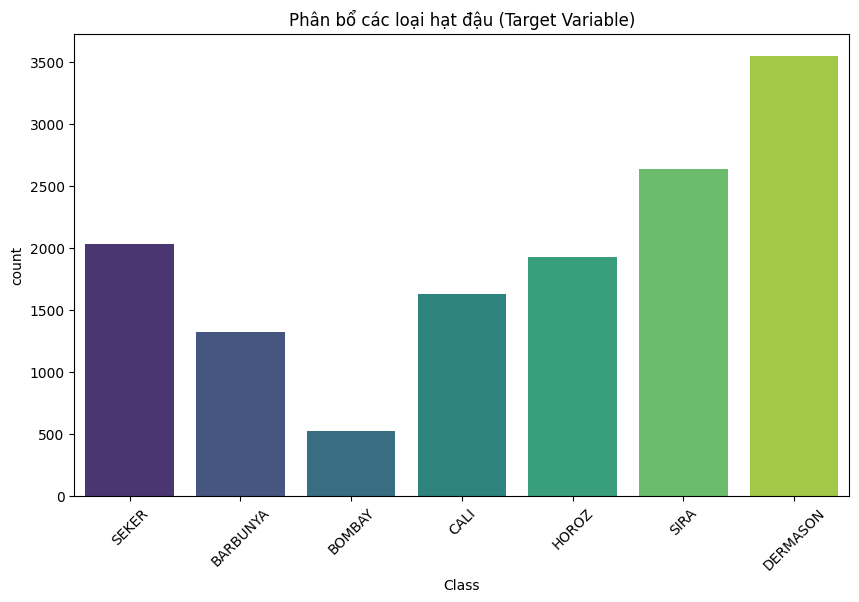

In [47]:

# Phân bố của biến mục tiêu 'Class'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Class', palette='viridis')
plt.title('Phân bổ các loại hạt đậu (Target Variable)')
plt.xticks(rotation=45)
plt.show()

### 3. Ma trận tương quan

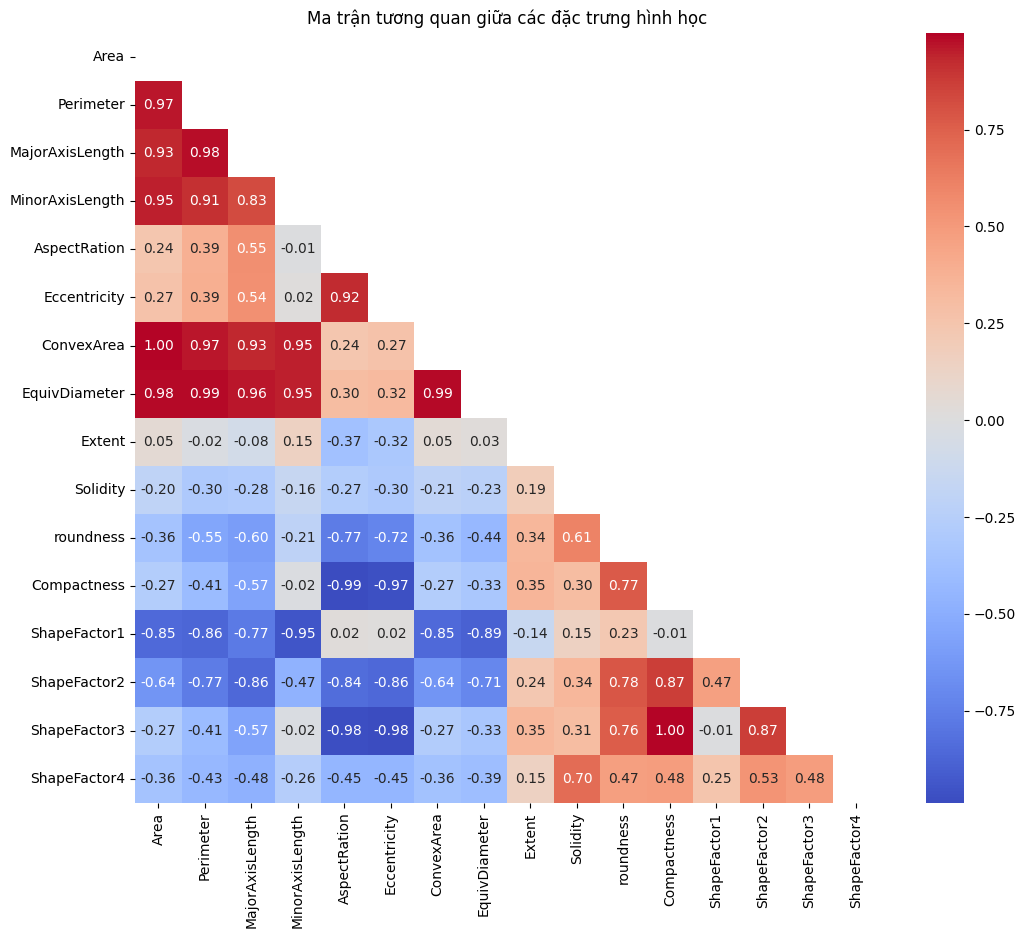

In [48]:
plt.figure(figsize=(12, 10))
# Chỉ tính toán tương quan trên các cột số
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Ma trận tương quan giữa các đặc trưng hình học')
plt.show()

### 4. Phát hiện ngoại lai (outliers) bằng phương pháp IQR hoặc Z-score. 

In [49]:
# 1. Phát hiện ngoại lai cho một cột ví dụ 'Area'
Q1 = df['Area'].quantile(0.25)
Q3 = df['Area'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = df[(df['Area'] < lower_bound) | (df['Area'] > upper_bound)].shape[0]
print(f"Số lượng ngoại lai trong cột Area: {outliers_count}")


Số lượng ngoại lai trong cột Area: 551


## 3. Tiền xử lý:

### 1. Xử lý giá trị còn thiếu (missing values): nếu có


In [ ]:
# 2. Kiểm tra giá trị thiếu
print("\nGiá trị thiếu mỗi cột:")
print(df.isnull().sum()) # Thường tập Dry Bean rất sạch, không có giá trị thiếu

# 3. Mã hóa biến mục tiêu (Chuyển tên đậu thành số: 0, 1, 2...)
le = LabelEncoder()
df['Class_Encoded'] = le.fit_transform(df['Class'])


# 4. Xuất dữ liệu sạch ra file CSV (Lưu lại trước khi chia Train/Test)
df.to_csv('data/dataset.csv', index=False)
print("\nĐã xuất dữ liệu ra file 'dataset.csv' thành công.")


Giá trị thiếu mỗi cột:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Đã xuất dữ liệu ra file 'dataset.csv' thành công.


### 2. Tách Feature

In [51]:
# Tách Features (X) và Target (y)
X = df.drop(['Class', 'Class_Encoded'], axis=1)
y = df['Class_Encoded']

# Chia 70% Train + Val và 20% Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Chia 80% (Train_Val) thành 70% (Train) và 10% (Val) tổng số
# 0.125 * 0.8 = 0.1
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)


### 3. Chuẩn hóa dữ liệu

In [52]:

# Chuẩn hóa dữ liệu (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nKích thước tập Train: {X_train_scaled.shape}")
print(f"Kích thước tập Validation: {X_val_scaled.shape}")
print(f"Kích thước tập Test: {X_test_scaled.shape}")


Kích thước tập Train: (9527, 16)
Kích thước tập Validation: (1361, 16)
Kích thước tập Test: (2723, 16)


In [53]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.model_selection import train_test_split

# # STEP 1: DATA INGESTION
# file = 'Dry_Bean_Dataset.xlsx'
# try:
#     df = pd.read_excel(file)
# except Exception as e:
#     print(f"Error loading file: {e}")

# # STEP 2: GLOBAL DATA CLEANING & IMPUTATION
# # Identify numeric and categorical columns across the entire dataframe
# numeric_cols = df.select_dtypes(include=[np.number]).columns
# non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns

# # Fill missing numeric values with the median (Robust to outliers)
# num_imputer = SimpleImputer(strategy='median')
# df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# # Handle categorical features (excluding the 'Class' target column)
# feature_non_numeric = [col for col in non_numeric_cols if col != 'Class']
# if feature_non_numeric:
#     cat_imputer = SimpleImputer(strategy='most_frequent')
#     df[feature_non_numeric] = cat_imputer.fit_transform(df[feature_non_numeric])
    
#     # Convert text categories into numerical labels
#     for col in feature_non_numeric:
#         le = LabelEncoder()
#         df[col] = le.fit_transform(df[col].astype(str))

# # STEP 3: EXPORTING CLEANED RAW DATA
# # Saving the dataset after imputation but before normalization
# df.to_csv('dataset.csv', index=False)
# print("Data cleaned and saved to 'dataset.csv'.")

# # STEP 4: FEATURE AND TARGET SEPARATION
# X = df.drop('Class', axis=1)
# y = df['Class']

# # STEP 5: DATASET PARTITIONING (TRAIN-TEST SPLIT)
# # Creating an 80/20 split to evaluate model performance later
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # STEP 6: TARGET VARIABLE ENCODING
# # Converting bean names (Seki, etc.) into integer labels
# target_le = LabelEncoder()
# y_train = target_le.fit_transform(y_train)
# y_test = target_le.transform(y_test)

# # STEP 7: FEATURE SCALING (Z-SCORE NORMALIZATION)
# # Centering features at 0 with unit variance to help model convergence
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # STEP 8: FINAL PREPROCESSING VERIFICATION
# print("--- Summary ---")
# print(f"Total Features: {X_train_scaled.shape[1]}")
# print(f"Encoded Classes: {target_le.classes_}")